# Explore here

In [2]:
# Your code here
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
categoricas = df.select_dtypes(include=['str']).columns.tolist()
categoricas

['sex', 'smoker', 'region']

In [6]:
numericas = df.select_dtypes(exclude=['str']).columns.tolist()
numericas

['age', 'bmi', 'children', 'charges']

In [7]:
df.duplicated().sum()

np.int64(1)

In [9]:
if df.duplicated().sum():
    df.drop_duplicates(inplace=True)
df.shape

(1337, 7)

In [10]:
for columna in categoricas:
    df[columna] = pd.factorize(df[columna])[0]
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int64  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   int64  
 5   region    1337 non-null   int64  
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 83.6 KB


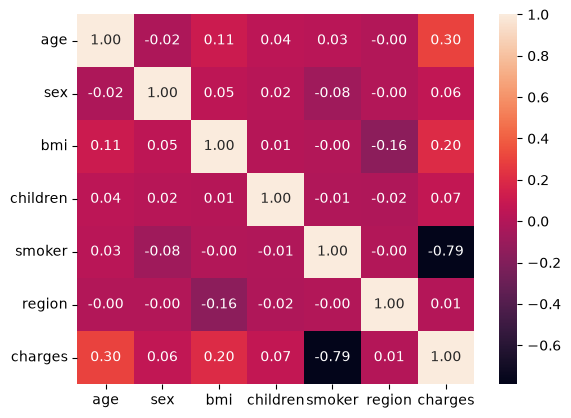

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f'
)

plt.show()

In [12]:
df_var = df[['age','bmi','smoker','charges']]

In [14]:
df_var.describe()

,age,bmi,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,0.795064,13279.121487
std,14.044333,6.100468,0.403806,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,1.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,1.000000,16657.717450
max,64.000000,53.130000,1.000000,63770.428010


In [15]:
X = df_var.drop(columns=['charges'])
y = df_var['charges']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

X_train.head()

,age,bmi,smoker
1114,23,24.510,1
968,21,25.745,1
599,52,37.525,1
170,63,41.470,1
275,47,26.600,1


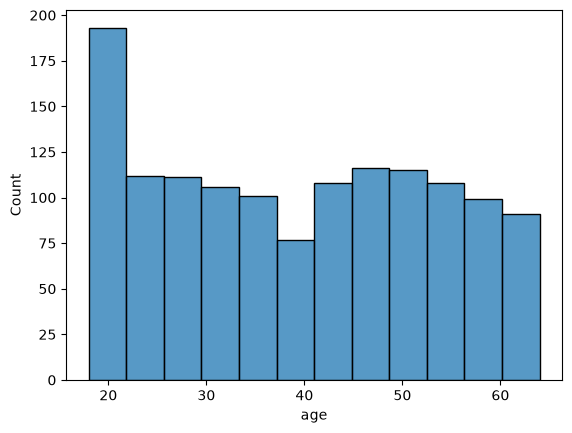

In [17]:
sns.histplot(data=df_var,x='age')

plt.show()

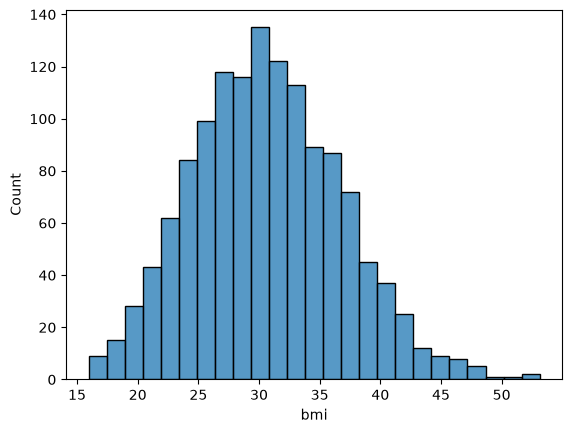

In [18]:
sns.histplot(data=df_var,x='bmi')

plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() 

X_train_esc = scaler.fit_transform(X_train, y_train)
X_test_esc = scaler.transform(X_test)

X_train_esc = pd.DataFrame(X_train_esc,columns=X_train.columns,index=X_train.index)
X_test_esc = pd.DataFrame(X_test_esc, columns=X_test.columns,index=X_test.index)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_esc,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 11586.3 , 11329.51,-23074.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','smoker']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.17e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [22]:
print(f'Intercepto:{model.intercept_}')
print(f'Coeficientes:{model.coef_}')

Intercepto:21701.79391257018
Coeficientes:[ 11586.30415359  11329.51105637 -23074.26173498]


In [23]:
y_pred = model.predict(X_test_esc)
y_pred

array([ 8433.67443577,  4336.46678013, 13165.0382606 , 30593.69534864,
        8738.64384303, 13004.1887831 , 29273.63576136,  2177.09021482,
       10922.95093736, 10315.83022735, 11021.84491859, 33740.33309282,
       30613.92158231, 18004.87150727,  9656.23179762,  9311.37354392,
        4325.12010919, 32099.96630635,  3001.71338943,  5552.62898392,
        4325.12010919, 29913.00795743, 14580.01800456, 30752.45719245,
       31444.92261851,  4769.02189756, 35187.05259131, 37413.46842278,
       10952.8675722 , 12177.75978526,  6505.9651105 , 13121.95183512,
         870.87899962, 12471.87695664, 40355.37672202, 12499.04467281,
        2732.11267963,  2866.20850841, 32023.18474965,  9365.1280589 ,
        6903.0538664 , 29243.81679061, 34097.79751626, 11919.91981386,
        6896.22734444,  4145.55111435,  6040.33037213,  9173.38425823,
        4186.69945959,  8909.59778913,  6340.1295272 , 12053.6361681 ,
       30836.41015271,  4425.70495311, 10719.84316929,  9666.05445578,
      

In [24]:
from sklearn.metrics import root_mean_squared_error, r2_score

print(f'RMSE:{root_mean_squared_error(y_test,y_pred)}')
print(f'R2:{r2_score(y_test,y_pred)}')

RMSE:5986.783344847844
R2:0.8049502474643171
